# 03. Autoencoder Training dan Latent Feature Extraction

In [1]:
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

from sklearn.metrics import mean_squared_error

In [2]:
import os
import random
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def get_project_root():
    cwd = Path.cwd().resolve()
    if cwd.name.lower() == "notebooks":
        return cwd.parent
    return cwd

PROJECT_ROOT = get_project_root()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FEATURES_DIR = RESULTS_DIR / "features"

for path in [DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR, FEATURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)

Project root: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST


In [3]:
CONFIG = {
    "random_seed": 42,
    "input_dim": 784,
    "latent_dim": 32,
    "batch_size": 128,
    "epochs": 20,
    "learning_rate": 0.001,
    "visualization_subset": 2000,
}

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["random_seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device digunakan:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device digunakan: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [4]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root=DATA_DIR, train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root=DATA_DIR, train=False, download=True, transform=transform)
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=0)
print("Train size:", len(train_dataset))
print("Test size :", len(test_dataset))

Train size: 60000
Test size : 10000


In [5]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim=784, latent_dim=32):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = x.view(x.size(0), -1)
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed
    def encode(self, x):
        x = x.view(x.size(0), -1)
        return self.encoder(x)

model = Autoencoder(CONFIG["input_dim"], CONFIG["latent_dim"]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


In [6]:
def train_autoencoder(model, dataloader, criterion, optimizer, device, epochs):
    history = []
    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0
        for images, _ in dataloader:
            images = images.to(device)
            inputs = images.view(images.size(0), -1)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)
        epoch_loss = running_loss / total_samples
        history.append({"epoch": epoch + 1, "train_loss": epoch_loss})
        print(f"Epoch {epoch+1:02d}/{epochs} | Reconstruction Loss: {epoch_loss:.6f}")
    return pd.DataFrame(history), time.time() - start_time

loss_history_df, training_time = train_autoencoder(model, train_loader, criterion, optimizer, device, CONFIG["epochs"])
print("Training selesai.")
print("Waktu training:", training_time, "detik")

Epoch 01/20 | Reconstruction Loss: 0.037038
Epoch 02/20 | Reconstruction Loss: 0.020368
Epoch 03/20 | Reconstruction Loss: 0.017789
Epoch 04/20 | Reconstruction Loss: 0.016192
Epoch 05/20 | Reconstruction Loss: 0.015016
Epoch 06/20 | Reconstruction Loss: 0.014125
Epoch 07/20 | Reconstruction Loss: 0.013364
Epoch 08/20 | Reconstruction Loss: 0.012750
Epoch 09/20 | Reconstruction Loss: 0.012265
Epoch 10/20 | Reconstruction Loss: 0.011854
Epoch 11/20 | Reconstruction Loss: 0.011523
Epoch 12/20 | Reconstruction Loss: 0.011220
Epoch 13/20 | Reconstruction Loss: 0.010979
Epoch 14/20 | Reconstruction Loss: 0.010708
Epoch 15/20 | Reconstruction Loss: 0.010510
Epoch 16/20 | Reconstruction Loss: 0.010285
Epoch 17/20 | Reconstruction Loss: 0.010114
Epoch 18/20 | Reconstruction Loss: 0.009952
Epoch 19/20 | Reconstruction Loss: 0.009803
Epoch 20/20 | Reconstruction Loss: 0.009671
Training selesai.
Waktu training: 164.42070984840393 detik


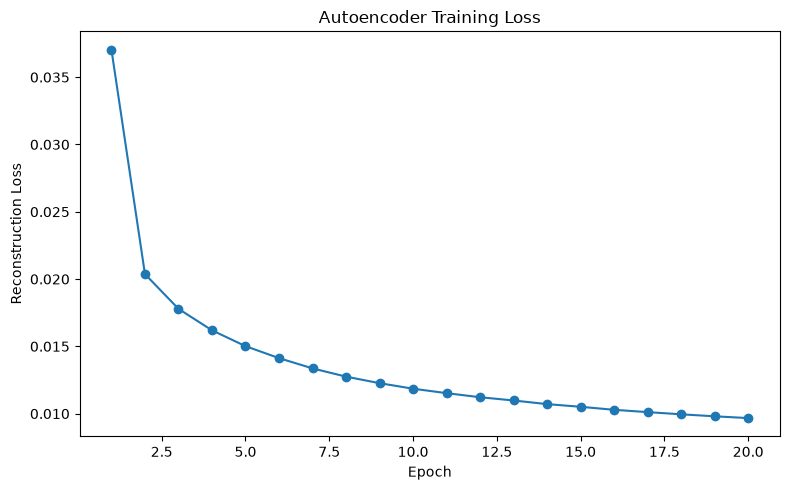

Grafik loss disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\autoencoder_training_loss.png


In [7]:
loss_history_path = RESULTS_DIR / "autoencoder_loss_history.csv"
loss_history_df.to_csv(loss_history_path, index=False)
plt.figure(figsize=(8, 5))
plt.plot(loss_history_df["epoch"], loss_history_df["train_loss"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Autoencoder Training Loss")
plt.tight_layout()
loss_plot_path = FIGURES_DIR / "autoencoder_training_loss.png"
plt.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print("Grafik loss disimpan ke:", loss_plot_path)

In [8]:
def fixed_indices(dataset_length, subset_size, seed=42):
    subset_size = min(subset_size, dataset_length)
    rng = np.random.RandomState(seed)
    return rng.choice(dataset_length, size=subset_size, replace=False)

visualization_indices = fixed_indices(len(test_dataset), CONFIG["visualization_subset"], CONFIG["random_seed"])
test_subset = Subset(test_dataset, visualization_indices)
test_loader = DataLoader(test_subset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=0)

def extract_latent_and_reconstruction(model, dataloader, device):
    model.eval()
    originals, labels, latents, reconstructions = [], [], [], []
    with torch.no_grad():
        for images, batch_labels in dataloader:
            images = images.to(device)
            flat_images = images.view(images.size(0), -1)
            latent = model.encode(images)
            reconstructed = model(images)
            originals.append(flat_images.cpu().numpy())
            labels.append(batch_labels.numpy())
            latents.append(latent.cpu().numpy())
            reconstructions.append(reconstructed.cpu().numpy())
    return np.vstack(originals), np.concatenate(labels), np.vstack(latents), np.vstack(reconstructions)

X_test_original, y_test_vis, autoencoder_latent, autoencoder_reconstructed = extract_latent_and_reconstruction(model, test_loader, device)
autoencoder_mse = mean_squared_error(X_test_original, autoencoder_reconstructed)
print("Original shape       :", X_test_original.shape)
print("Latent shape         :", autoencoder_latent.shape)
print("Reconstruction shape :", autoencoder_reconstructed.shape)
print("Autoencoder MSE      :", autoencoder_mse)

Original shape       : (2000, 784)
Latent shape         : (2000, 32)
Reconstruction shape : (2000, 784)
Autoencoder MSE      : 0.010139469988644123


In [9]:
np.save(FEATURES_DIR / "autoencoder_latent_features.npy", autoencoder_latent)
np.save(FEATURES_DIR / "autoencoder_reconstructed.npy", autoencoder_reconstructed)
if not (FEATURES_DIR / "raw_features.npy").exists():
    np.save(FEATURES_DIR / "raw_features.npy", X_test_original)
if not (FEATURES_DIR / "labels.npy").exists():
    np.save(FEATURES_DIR / "labels.npy", y_test_vis)

model_path = MODELS_DIR / "autoencoder_fashionmnist.pth"
torch.save({"model_state_dict": model.state_dict(), "config": CONFIG, "reconstruction_mse": autoencoder_mse}, model_path)

autoencoder_results = pd.DataFrame([{
    "method": "Autoencoder",
    "input_dim": CONFIG["input_dim"],
    "latent_dim": CONFIG["latent_dim"],
    "train_size": len(train_dataset),
    "test_size": len(X_test_original),
    "reconstruction_mse": autoencoder_mse,
    "epochs": CONFIG["epochs"],
    "batch_size": CONFIG["batch_size"],
    "learning_rate": CONFIG["learning_rate"],
    "training_time_seconds": training_time
}])
autoencoder_results_path = RESULTS_DIR / "autoencoder_results.csv"
autoencoder_results.to_csv(autoencoder_results_path, index=False)
display(autoencoder_results)
print("Model Autoencoder disimpan ke:", model_path)
print("Hasil Autoencoder disimpan ke:", autoencoder_results_path)

,method,input_dim,latent_dim,train_size,test_size,reconstruction_mse,epochs,batch_size,learning_rate,training_time_seconds
0,Autoencoder,784,32,60000,2000,0.010139,20,128,0.001,164.42071


Model Autoencoder disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\models\autoencoder_fashionmnist.pth
Hasil Autoencoder disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\autoencoder_results.csv


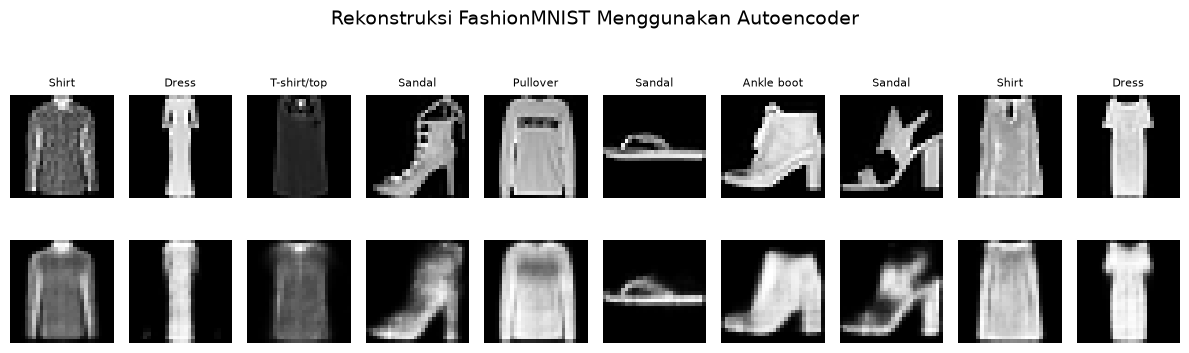

Gambar rekonstruksi disimpan ke: D:\Code\PCA_vs_Autoencoder_FashionMNIST_Project\PCA_vs_Autoencoder_FashionMNIST\results\figures\autoencoder_reconstruction.png


In [10]:
def show_reconstruction(original, reconstructed, labels, class_names, title, output_file, n=10):
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, n, i + 1)
        plt.imshow(original[i].reshape(28, 28), cmap="gray")
        plt.title(class_names[labels[i]], fontsize=8)
        plt.axis("off")
        plt.subplot(2, n, i + 1 + n)
        plt.imshow(reconstructed[i].reshape(28, 28), cmap="gray")
        plt.axis("off")
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    output_path = FIGURES_DIR / output_file
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Gambar rekonstruksi disimpan ke:", output_path)

show_reconstruction(X_test_original, autoencoder_reconstructed, y_test_vis, class_names, "Rekonstruksi FashionMNIST Menggunakan Autoencoder", "autoencoder_reconstruction.png")